In [1]:
from pathlib import Path
import os
import yaml

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pprint import pprint

import torch
import seaborn as sns

use_cuda = torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('../../')
sys.path.append('../')

from train_controller import build_controller
from train_controller import forward_pass 
from reach_plot_utils import eval_and_plot, plot_losses

In [5]:
from src import plot_utils as pu 
from src import analysis_utils as au 
from src import eg_utils

[]
No fonts found


# Defining folders with experiments 

In [11]:
linclab_drive  = Path("/network/projects/_groups/linclab_users/eg/")
project_folder = linclab_drive/"reach_cosdecay"
os.listdir(project_folder)

['6k500irrel']

In [12]:
all_exps_folder = project_folder/"6k500irrel"

In [13]:
os.listdir(all_exps_folder)

['rnn_2500_seg_lr0.4_m0.925_wd1e-06_mxn4_bs500_cosinecooldown_nirrel500_updates6000_rdl',
 'rnn_2500_seg_lr0.6_m0.925_wd1e-06_mxn4_bs500_cosinecooldown_nirrel500_updates6000_rdl',
 'rnn_2500_sgd_lr0.01_m0.925_wd1e-05_mxn4_bs500_cosinecooldown_nirrel500_updates6000_rdl',
 'rnn_2500_sgd_lr0.05_m0.925_wd1e-05_mxn4_bs500_cosinecooldown_nirrel500_updates6000_rdl',
 'rnn_2500_seg_lr0.6_m0.925_wd1e-06_mxn2.5_bs500_cosinecooldown_nirrel500_updates6000_rdl',
 'rnn_2500_seg_lr0.4_m0.925_wd1e-06_mxn2.5_bs500_cosinecooldown_nirrel500_updates6000_rdl',
 'rnn_2500_seg_lr0.4_m0.925_wd1e-06_mxn2.5_bs500_cosinecooldown_nirrel500_updates6000',
 'rnn_2500_sgd_lr0.01_m0.925_wd1e-05_mxn4_bs500_cosinecooldown_nirrel500_updates6000',
 'rnn_2500_seg_lr0.6_m0.925_wd1e-06_mxn2.5_bs500_cosinecooldown_nirrel500_updates6000',
 'rnn_2500_sgd_lr0.005_m0.925_wd1e-05_mxn4_bs500_cosinecooldown_nirrel500_updates6000',
 'rnn_2500_seg_lr0.75_m0.925_wd1e-06_mxn4_bs500_cosinecooldown_nirrel0_updates6000',
 'rnn_2500_sgd_lr0

In [14]:
exp_folders = {
    "gd_500" : "rnn_2500_sgd_lr0.01_m0.925_wd1e-05_mxn4_bs500_cosinecooldown_nirrel500_updates6000",
    "gd_0"   : "rnn_2500_sgd_lr0.05_m0.925_wd1e-05_mxn4_bs500_cosinecooldown_nirrel0_updates6000",
    "eg_500" : "rnn_2500_seg_lr0.4_m0.925_wd1e-06_mxn2.5_bs500_cosinecooldown_nirrel500_updates6000",
    "eg_0"   : "rnn_2500_seg_lr0.75_m0.925_wd1e-06_mxn4_bs500_cosinecooldown_nirrel0_updates6000",
}

for k in exp_folders.keys():
    exp_folders[k] = all_exps_folder/exp_folders[k]
    
exp_folders

{'gd_500': PosixPath('/network/projects/_groups/linclab_users/eg/reach_cosdecay/6k500irrel/rnn_2500_sgd_lr0.01_m0.925_wd1e-05_mxn4_bs500_cosinecooldown_nirrel500_updates6000'),
 'gd_0': PosixPath('/network/projects/_groups/linclab_users/eg/reach_cosdecay/6k500irrel/rnn_2500_sgd_lr0.05_m0.925_wd1e-05_mxn4_bs500_cosinecooldown_nirrel0_updates6000'),
 'eg_500': PosixPath('/network/projects/_groups/linclab_users/eg/reach_cosdecay/6k500irrel/rnn_2500_seg_lr0.4_m0.925_wd1e-06_mxn2.5_bs500_cosinecooldown_nirrel500_updates6000'),
 'eg_0': PosixPath('/network/projects/_groups/linclab_users/eg/reach_cosdecay/6k500irrel/rnn_2500_seg_lr0.75_m0.925_wd1e-06_mxn4_bs500_cosinecooldown_nirrel0_updates6000')}

In [15]:
def load_results(exp_folders, verbose=False):
    # could have just used exp_folders, but making an explicit results_dict
    results_dict = au.DotDict({})
    for exp_name, exp_folder in exp_folders.items():
        results_dict[exp_name] = au.DotDict({"exp_path": exp_folder})

    # load the results 
    for exp_name in results_dict.keys():
        #print(results_dict[exp_name].exp_path)
        print(exp_name, end="")
        found, not_found = 0, 0
        seed_dirs= sorted(os.listdir(exp_folders[exp_name]), key=lambda x: int(x.split("_")[-1]))
        for seed_dir in seed_dirs[:]:
            results_dict[exp_name][seed_dir] = au.DotDict({"path": results_dict[exp_name].exp_path/seed_dir})

            checkpoints = list(results_dict[exp_name][seed_dir].path.glob("*.pth"))
            if len(checkpoints) == 0:
                print("No epoch_ckpts found")
            else:
                results_dict[exp_name][seed_dir]["ckpts"] = checkpoints
            try:
                results_dict[exp_name][seed_dir].results = np.load(results_dict[exp_name][seed_dir].path/"results.npy", allow_pickle=True)[()]
                found += 1
            except:
                not_found +=1

            # load the config into a dict
            with open(results_dict[exp_name][seed_dir].path/"config.yaml", 'r') as file:
                # print("Loading config", results_dict[exp_name][seed_dir].path/"config.yaml")
                config = au.DotDict(yaml.safe_load(file))
                cfg = au.recursive_dot_dict(config)
                results_dict[exp_name][seed_dir].cfg = cfg 

                #print(cfg.exp.n_irrel_feats)

        if verbose: print(f" : loaded {found} results from {found+not_found}")
    return results_dict



In [16]:
results_dict = load_results(exp_folders, verbose=True)

gd_500 : loaded 9 results from 9
gd_0 : loaded 9 results from 9
eg_500 : loaded 9 results from 9
eg_0 : loaded 9 results from 9


In [17]:
def concat_seed_results(exp_d, verbose=False):
    exp_results = au.DotDict({})
    for seed_key in exp_d.keys():
        if not seed_key.startswith("seed"): continue
        assert isinstance(exp_d[seed_key], dict)
        try:
            assert "results" in exp_d[seed_key]
        except:
            print(f"Skipping {seed_key}")
            continue
        if verbose:
            print(seed_key, exp_d[seed_key].results["loss"][-1])
        exp_results = au.concat_dict(exp_results, exp_d[seed_key].results, axis=1)
    
    exp_d.results = exp_results
    return au.DotDict(exp_d)

In [18]:
def get_best_seed(exp_d, verbose=True):
    exp_results = au.DotDict({})
    best_seed = None
    for seed_key in exp_d.keys():
        if not seed_key.startswith("seed"): continue
        assert isinstance(exp_d[seed_key], dict)
        
        final_loss= exp_d[seed_key].results["loss"][-1]
        if best_seed is None:
            best_seed = (seed_key, final_loss)
        if final_loss < best_seed[1]:
            best_seed = (seed_key, final_loss)
            
    return best_seed


In [45]:
# print best seed
for exp_name in results_dict.keys():
    print(exp_name)
    print(get_best_seed(results_dict[exp_name]))
    

gd_500
('seed_7', 0.11623503267765045)
gd_0
('seed_9', 0.06799681484699249)
eg_500
('seed_8', 0.09487221390008926)
eg_0
('seed_79', 0.06867346167564392)


In [20]:
for exp_name in results_dict.keys():
    print(exp_name)
    results_dict[exp_name] = concat_seed_results(results_dict[exp_name], False)

gd_500
gd_0
eg_500
eg_0


In [21]:
results_dict.eg_500.c = "#f05039" # orangey red
results_dict.eg_0.c = "#f05039" # orangey red
eg_c = "#f05039" 

results_dict.gd_500.c = "#1f449c" # blue
results_dict.gd_0.c = "#1f449c" # blue
gd_c = "#1f449c"

In [22]:
list(results_dict.keys())

['gd_500', 'gd_0', 'eg_500', 'eg_0']

In [23]:
results_dict.gd_500.results.loss.shape

(6000, 9)

In [24]:
results_dict.gd_500.results.l1_loss.shape

(6000, 9)

In [25]:
results_dict.gd_500.results.keys()

dict_keys(['loss', 'rel_l1_loss', 'l1_loss', 'lr', 'grads_norm_before_clip', 'grads_norm_after_clip', 'hidden_reg', 'action_reg', 'Whh_norm', 'loss_auc', 'sigma_max'])

In [26]:
for k in list(results_dict.keys()):
    print(k, results_dict[k].results.keys())
    print(results_dict[k].results["loss"].shape)


gd_500 dict_keys(['loss', 'rel_l1_loss', 'l1_loss', 'lr', 'grads_norm_before_clip', 'grads_norm_after_clip', 'hidden_reg', 'action_reg', 'Whh_norm', 'loss_auc', 'sigma_max'])
(6000, 9)
gd_0 dict_keys(['loss', 'rel_l1_loss', 'l1_loss', 'lr', 'grads_norm_before_clip', 'grads_norm_after_clip', 'hidden_reg', 'action_reg', 'Whh_norm', 'loss_auc', 'sigma_max'])
(6000, 9)
eg_500 dict_keys(['loss', 'rel_l1_loss', 'l1_loss', 'lr', 'grads_norm_before_clip', 'grads_norm_after_clip', 'hidden_reg', 'action_reg', 'Whh_norm', 'loss_auc', 'sigma_max'])
(6000, 9)
eg_0 dict_keys(['loss', 'rel_l1_loss', 'l1_loss', 'lr', 'grads_norm_before_clip', 'grads_norm_after_clip', 'hidden_reg', 'action_reg', 'Whh_norm', 'loss_auc', 'sigma_max'])
(6000, 9)


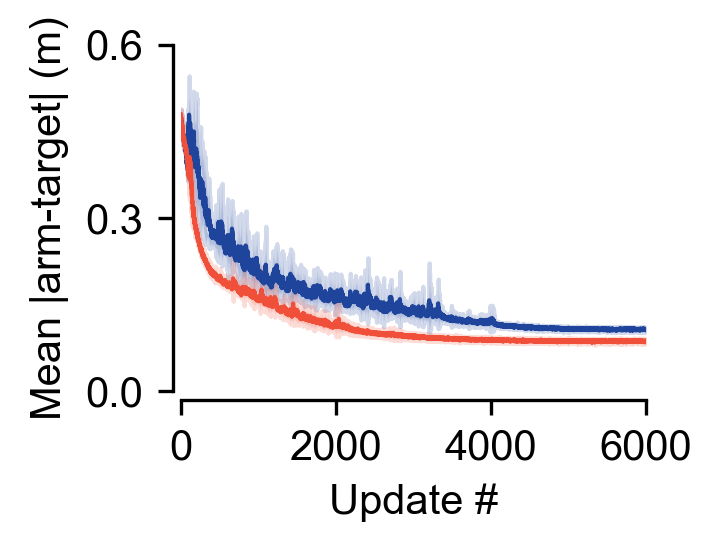

In [ ]:
plt.figure(figsize=(2.0,1.5), dpi = 300)

gd_arr = results_dict.gd_500.results.l1_loss
plt.fill_between(np.arange(1, gd_arr.shape[0]+1), 
                 gd_arr.mean(axis=1)-gd_arr.std(axis=1), gd_arr.mean(axis=1)+gd_arr.std(axis=1),
                 color=gd_c, alpha=0.2)

plt.plot(gd_arr.mean(axis=1), color=gd_c, alpha=1, lw=1)

eg_arr = results_dict.eg_500.results.l1_loss
#plt.plot(eg_arr, color=eg_c, alpha=0.1)
plt.fill_between(np.arange(1, eg_arr.shape[0]+1), 
                 eg_arr.mean(axis=1)-eg_arr.std(axis=1), eg_arr.mean(axis=1)+eg_arr.std(axis=1),
                 color=eg_c, alpha=0.2)
plt.plot(eg_arr.mean(axis=1), color=eg_c, alpha=1, lw=1)


plt.ylim(0, 0.6)
plt.yticks([0, 0.3, 0.6])
plt.xlim(0, 6000)
plt.xlabel("Update #")
plt.ylabel("Mean |arm-target| (m)")

sns.despine(offset=2, trim=True)
#plt.savefig("cos_decay_l1_loss_curve_6k_500_irrel.pdf", bbox_inches="tight", transparent=True)

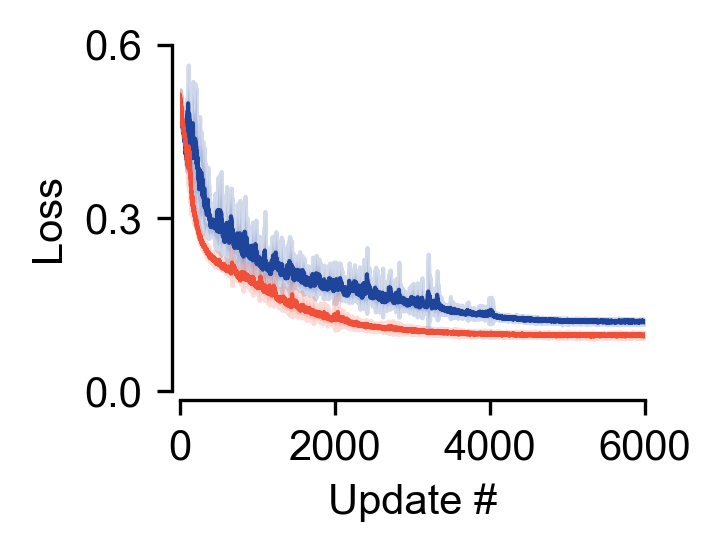

In [ ]:
plt.figure(figsize=(2.0,1.5), dpi = 300)

gd_arr = results_dict.gd_500.results.loss
plt.fill_between(np.arange(1, gd_arr.shape[0]+1), 
                 gd_arr.mean(axis=1)-gd_arr.std(axis=1), gd_arr.mean(axis=1)+gd_arr.std(axis=1),
                 color=gd_c, alpha=0.2)

plt.plot(gd_arr.mean(axis=1), color=gd_c, alpha=1, lw=1)

eg_arr = results_dict.eg_500.results.loss
#plt.plot(eg_arr, color=eg_c, alpha=0.1)
plt.fill_between(np.arange(1, eg_arr.shape[0]+1), 
                 eg_arr.mean(axis=1)-eg_arr.std(axis=1), eg_arr.mean(axis=1)+eg_arr.std(axis=1),
                 color=eg_c, alpha=0.2)
plt.plot(eg_arr.mean(axis=1), color=eg_c, alpha=1, lw=1)


plt.ylim(0, 0.6)
plt.yticks([0, 0.3, 0.6])
plt.xlim(0, 6000)
plt.xlabel("Update #")
plt.ylabel("Loss")

sns.despine(offset=2, trim=True)
#plt.savefig("cos_decay_loss_curve_6k_500_irrel.pdf", bbox_inches="tight", transparent=True)

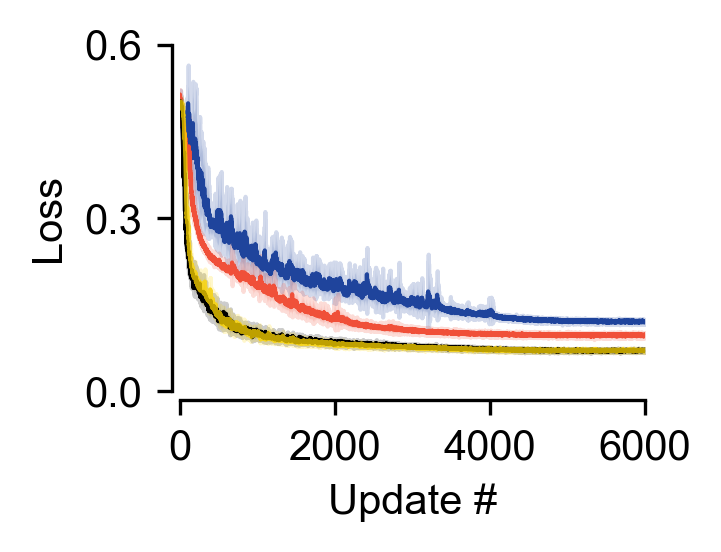

In [ ]:
plt.figure(figsize=(2.0,1.5), dpi = 300)

gd_arr = results_dict.gd_500.results.loss
plt.fill_between(np.arange(1, gd_arr.shape[0]+1), 
                 gd_arr.mean(axis=1)-gd_arr.std(axis=1), gd_arr.mean(axis=1)+gd_arr.std(axis=1),
                 color=gd_c, alpha=0.2)
plt.plot(gd_arr.mean(axis=1), color=gd_c, alpha=1, lw=1)

eg_arr = results_dict.eg_500.results.loss
plt.fill_between(np.arange(1, eg_arr.shape[0]+1), 
                 eg_arr.mean(axis=1)-eg_arr.std(axis=1), eg_arr.mean(axis=1)+eg_arr.std(axis=1),
                 color=eg_c, alpha=0.2)
plt.plot(eg_arr.mean(axis=1), color=eg_c, alpha=1, lw=1)

# ------------ # ----------------- # ---------
# Add in the zero distractors

gd_arr = results_dict.gd_0.results.loss
plt.fill_between(np.arange(1, gd_arr.shape[0]+1), 
                 gd_arr.mean(axis=1)-gd_arr.std(axis=1), gd_arr.mean(axis=1)+gd_arr.std(axis=1),
                 color="k", alpha=0.2)

plt.plot(gd_arr.mean(axis=1), color="k", alpha=1, lw=1)

eg_arr = results_dict.eg_0.results.loss
#plt.plot(eg_arr, color=eg_c, alpha=0.1)
plt.fill_between(np.arange(1, eg_arr.shape[0]+1), 
                 eg_arr.mean(axis=1)-eg_arr.std(axis=1), eg_arr.mean(axis=1)+eg_arr.std(axis=1),
                 color="gold", alpha=0.2)
plt.plot(eg_arr.mean(axis=1), color="gold", alpha=0.75, lw=1)

# --------------------

plt.ylim(0, 0.6)
plt.yticks([0, 0.3, 0.6])
plt.xlim(0, 6000)
plt.xlabel("Update #")
plt.ylabel("Loss")

sns.despine(offset=2, trim=True)
#plt.savefig("cos_decay_loss_curve_6k_both.pdf", bbox_inches="tight", transparent=True)

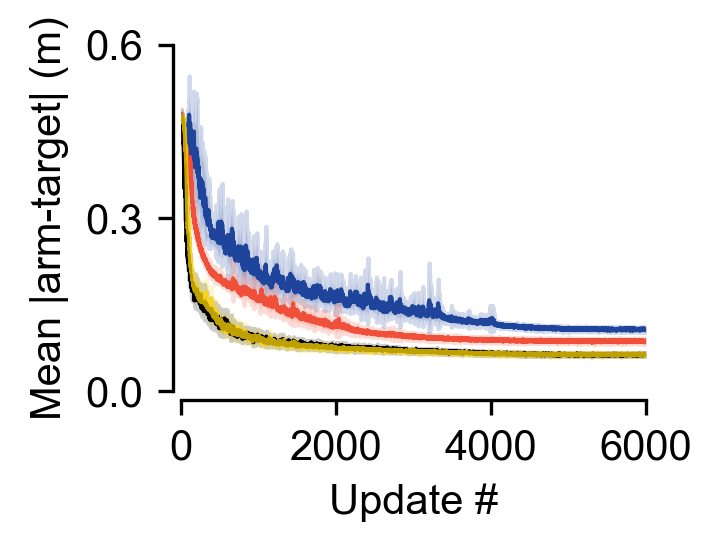

In [ ]:
plt.figure(figsize=(2.0,1.5), dpi = 300)

gd_arr = results_dict.gd_500.results.l1_loss
plt.fill_between(np.arange(1, gd_arr.shape[0]+1), 
                 gd_arr.mean(axis=1)-gd_arr.std(axis=1), gd_arr.mean(axis=1)+gd_arr.std(axis=1),
                 color=gd_c, alpha=0.2)
plt.plot(gd_arr.mean(axis=1), color=gd_c, alpha=1, lw=1)

eg_arr = results_dict.eg_500.results.l1_loss
plt.fill_between(np.arange(1, eg_arr.shape[0]+1), 
                 eg_arr.mean(axis=1)-eg_arr.std(axis=1), eg_arr.mean(axis=1)+eg_arr.std(axis=1),
                 color=eg_c, alpha=0.2)
plt.plot(eg_arr.mean(axis=1), color=eg_c, alpha=1, lw=1)

# ------------ # ----------------- # ---------
# Add in the zero distractors

gd_arr = results_dict.gd_0.results.l1_loss
plt.fill_between(np.arange(1, gd_arr.shape[0]+1), 
                 gd_arr.mean(axis=1)-gd_arr.std(axis=1), gd_arr.mean(axis=1)+gd_arr.std(axis=1),
                 color="k", alpha=0.2)

plt.plot(gd_arr.mean(axis=1), color="k", alpha=1, lw=1)

eg_arr = results_dict.eg_0.results.l1_loss
#plt.plot(eg_arr, color=eg_c, alpha=0.1)
plt.fill_between(np.arange(1, eg_arr.shape[0]+1), 
                 eg_arr.mean(axis=1)-eg_arr.std(axis=1), eg_arr.mean(axis=1)+eg_arr.std(axis=1),
                 color="gold", alpha=0.2)
plt.plot(eg_arr.mean(axis=1), color="gold", alpha=0.75, lw=1)

# --------------------

plt.ylim(0, 0.6)
plt.yticks([0, 0.3, 0.6])
plt.xlim(0, 6000)
plt.xlabel("Update #")
plt.ylabel("Mean |arm-target| (m)")

sns.despine(offset=2, trim=True)
#plt.savefig("cos_decay_l1_loss_curve_6k_both.pdf", bbox_inches="tight", transparent=True)

# Rest of the figure


In [31]:
results_dict.keys()

dict_keys(['gd_500', 'gd_0', 'eg_500', 'eg_0'])

In [32]:
results_dict.eg_500.seed_8.keys()

dict_keys(['path', 'ckpts', 'results', 'cfg'])

In [33]:
results_dict.eg_500.seed_8.ckpts

[PosixPath('/network/projects/_groups/linclab_users/eg/reach_cosdecay/6k500irrel/rnn_2500_seg_lr0.4_m0.925_wd1e-06_mxn2.5_bs500_cosinecooldown_nirrel500_updates6000/seed_8/init_model.pth'),
 PosixPath('/network/projects/_groups/linclab_users/eg/reach_cosdecay/6k500irrel/rnn_2500_seg_lr0.4_m0.925_wd1e-06_mxn2.5_bs500_cosinecooldown_nirrel500_updates6000/seed_8/controller_0.pth'),
 PosixPath('/network/projects/_groups/linclab_users/eg/reach_cosdecay/6k500irrel/rnn_2500_seg_lr0.4_m0.925_wd1e-06_mxn2.5_bs500_cosinecooldown_nirrel500_updates6000/seed_8/controller_1000.pth'),
 PosixPath('/network/projects/_groups/linclab_users/eg/reach_cosdecay/6k500irrel/rnn_2500_seg_lr0.4_m0.925_wd1e-06_mxn2.5_bs500_cosinecooldown_nirrel500_updates6000/seed_8/controller_2000.pth'),
 PosixPath('/network/projects/_groups/linclab_users/eg/reach_cosdecay/6k500irrel/rnn_2500_seg_lr0.4_m0.925_wd1e-06_mxn2.5_bs500_cosinecooldown_nirrel500_updates6000/seed_8/controller_3000.pth'),
 PosixPath('/network/projects/_gr

In [34]:
results_dict.keys()

dict_keys(['gd_500', 'gd_0', 'eg_500', 'eg_0'])

In [ ]:
def load_controller_from_run(run_dict):
    cfg = run_dict.cfg
    controller = build_controller(cfg)
    if cfg.opt.update_algorithm == "eg":
        eg_utils.set_split_bias(controller.policy)
    return controller

run_dict = results_dict.gd_500.seed_8
controller = load_controller_from_run(run_dict)

init_ckpt = run_dict.path/"controller_0.pth"
onek_ckpt = run_dict.path/"controller_1000.pth"
twok_ckpt = run_dict.path/"controller_2000.pth"
threek_ckpt = run_dict.path/"controller_3000.pth"
final_ckpt = run_dict.path/"controller_5999.pth"

muscle: cuda:0
skel init: cuda:0
effector init: cuda:0
env init: cuda:0


In [36]:
os.listdir(run_dict.path)

['config.yaml',
 'init_model.pth',
 'controller_0.pth',
 'eval_0.png',
 'eval_0.pdf',
 'eval_500.png',
 'eval_500.pdf',
 'controller_1000.pth',
 'eval_1000.png',
 'eval_1000.pdf',
 'eval_1500.png',
 'eval_1500.pdf',
 'controller_2000.pth',
 'eval_2000.png',
 'eval_2000.pdf',
 'eval_2500.png',
 'eval_2500.pdf',
 'controller_3000.pth',
 'eval_3000.png',
 'eval_3000.pdf',
 'eval_3500.png',
 'eval_3500.pdf',
 'controller_4000.pth',
 'eval_4000.png',
 'eval_4000.pdf',
 'eval_4500.png',
 'eval_4500.pdf',
 'controller_5000.pth',
 'eval_5000.png',
 'eval_5000.pdf',
 'eval_5500.png',
 'eval_5500.pdf',
 'eval_5999.png',
 'eval_5999.pdf',
 'controller_5999.pth',
 'results.npy']

In [37]:
scale_dist_x = 0.04
scale_dist_y = 0.04
graph_width = 6.0
graph_height = 4.0
key_dist = 0.04

def plot_scalebars(ax, div=3.0, labels=True,
                   xunits="", yunits="", nox=False,
                   sb_xoff=0, sb_yoff=0,
                   sb_ylabel_xoff_comp=False, sb_ylabel_yoff=0,
                   rotate_yslabel=False,
                   linestyle="-k", linewidth=4.0,
                   textcolor='k', textweight='normal',
                   xmin=None, xmax=None, ymin=None, ymax=None):
    scale_dist_x = 1# 0.04
    scale_dist_y = 1# 0.04

    # print dir(ax.dataLim)
    if xmin is None:
        xmin = ax.dataLim.xmin
    if xmax is None:
        xmax = ax.dataLim.xmax
    if ymin is None:
        ymin = ax.dataLim.ymin
    if ymax is None:
        ymax = ax.dataLim.ymax
    xscale = xmax-xmin
    yscale = ymax-ymin

    xoff = (scale_dist_x + sb_xoff) * xscale
    if sb_ylabel_xoff_comp:
        xoff_ylabel = scale_dist_x * xscale
    else:
        xoff_ylabel = xoff

    yoff = (scale_dist_y - sb_yoff) * yscale

    # plot scale bars:
    xlength = prettyNumber((xmax-xmin)/div)
    xend_x, xend_y = xmax, ymin
    if not nox:
        xstart_x, xstart_y = xmax-xlength, ymin
        scalebarsx = [xstart_x+xoff, xend_x+xoff]
        scalebarsy = [xstart_y-yoff, xend_y-yoff]
    else:
        scalebarsx = [xend_x+xoff, ]
        scalebarsy = [xend_y-yoff]

    ylength = prettyNumber((ymax-ymin)/div)
    yend_x, yend_y = xmax, ymin+ylength
    scalebarsx.append(yend_x+xoff)
    scalebarsy.append(yend_y-yoff)

    ax.plot(scalebarsx, scalebarsy, linestyle, linewidth=linewidth,
            solid_joinstyle='miter')

    if labels:
        # if textcolor is not None:
        #     color = "\color{%s}" % textcolor
        # else:
        #     color = ""
        if not nox:
            # xlabel
            if xlength >= 1:
                xlabel = r"%d$\,$%s" % (xlength, xunits)
            else:
                xlabel = r"%g$\,$%s" % (xlength, xunits)
            xlabel_x, xlabel_y = xmax-xlength/2.0, ymin
            xlabel_y -= key_dist*yscale
            ax.text(
                xlabel_x+xoff, xlabel_y-yoff, xlabel, ha='center', va='top',
                weight=textweight, color=textcolor)
        # ylabel
        if ylength >= 1:
            ylabel = r"%d$\,$%s" % (ylength, yunits)
        else:
            ylabel = r"%g$\,$%s" % (ylength, yunits)
        if not rotate_yslabel:
            ylabel_x, ylabel_y = \
                xmax, ymin + ylength/2.0 + sb_ylabel_yoff*yscale
            ylabel_x += key_dist*xscale
            ax.text(ylabel_x+xoff_ylabel, ylabel_y-yoff, ylabel,
                    ha='left', va='center',
                    weight=textweight, color=textcolor)
        else:
            ylabel_x, ylabel_y = xmax, ymin + ylength/2.0 + sb_ylabel_yoff
            ylabel_x += key_dist*xscale
            ax.text(ylabel_x+xoff_ylabel, ylabel_y-yoff, ylabel,
                    ha='left', va='center', rotation=90,
                    weight=textweight, color=textcolor)


def xFormat(x, res, data_len, width):
    points = int(width/2.5 * res)
    part = float(x) / data_len
    return int(part*points)


def yFormat(y):
    return y

def prettyNumber(f):
    fScaled = f
    if fScaled < 1:
        correct = 10.0
    else:
        correct = 1.0

    # set stepsize
    try:
        nZeros = int(np.log10(fScaled))
    except OverflowError:
        nZeros = 0

    prev10e = 10.0**nZeros / correct
    next10e = prev10e * 10

    if fScaled / prev10e > 7.5:
        return next10e
    elif fScaled / prev10e > 5.0:
        return 5 * prev10e
    else:
        return round(fScaled/prev10e) * prev10e

In [38]:
def tensor(x): return x if torch.is_tensor(x) else torch.tensor(x).to(device).float()
# clone and detach is pointless?
def detach(x): return x.clone().detach().cpu().numpy()

def plot_reaches(env_fingertip, targets, title_str=None, 
                 ylims=None, xlims=None, c=None, scale_bars=True):
    
    x = env_fingertip[:, :, 0]
    y = env_fingertip[:, :, 1]
    
    xt = targets[-1, :, 0] # -1 for last timestep
    yt = targets[-1, :, 1]
    
    fig = plt.figure(figsize=(1.5, 1.5), dpi=300)
    if c is None: plt.plot(x, y)
    else: plt.plot(x, y, c)
    plt.scatter(x[0,:], y[0,:], marker="x", color="k", s=20) # starting
    
    plt.scatter(xt, yt, marker="o", color="k", s=6)
    plt.xlabel("X position (m)")
    plt.ylabel("Y position (m)")
    
    if title_str is not None:
        plt.title(title_str)
    
    if ylims is None: 
        plt.ylim(0, 0.7) 
    else: 
        plt.ylim(*ylims)
    
    if xlims is None: 
        plt.xlim(-0.7, 0.7) 
    else: 
        plt.xlim(*xlims)
    
    if scale_bars:
        ax = plt.gca()
        # Remove the default axes
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)

        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

#         plot_scalebars(ax, xmin=0, xmax=0.2, ymin=0, ymax=0.2, div=1)
        
        # Add scale bars (adjust the length and position to your needs)
        # Scale bar for time (X-axis, e.g., 20 ms)
        _, xmax = plt.xlim() 
        x_bar_length = 0.2
        bar_yorig = 0.1
        ax.plot([xmax-x_bar_length, xmax], [bar_yorig, bar_yorig], color='black', lw=1)  # horizontal scale bar for time
        #ax.text(time_bar_length / 2, -87, f'{time_bar_length} ms', ha='center')

        # Scale bar for voltage (Y-axis, e.g., 10 mV)
        y_bar_length = 0.2
        ax.plot([xmax-x_bar_length, xmax-x_bar_length], [bar_yorig, bar_yorig+y_bar_length], color='black', lw=1)  # vertical scale bar for voltage
        #ax.text(2, -85 + voltage_bar_length / 2, f'{voltage_bar_length} mV', va='center')
    
    return fig

In [39]:
def load_checkpoint(controller, ckpt):
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    state_dict = torch.load(ckpt, map_location=device, weights_only=True)
    controller.load_state_dict(state_dict)

def run_controller(controller, eval_bool, ckpt=None):
    from train_controller import forward_pass 
    if ckpt is not None: load_checkpoint(controller, ckpt)

    outputs = forward_pass(controller, batch_size=8, n_timesteps=100, eval_mode=eval_bool)
    env_fingertip = np.stack([detach(obs) for obs in outputs["env_fingertip"]])
    targets = np.stack([detach(obs) for obs in outputs["env_goal"]])
    
    return outputs, env_fingertip, targets

outputs, env_fingertip, targets = run_controller(controller, eval_bool=False, ckpt=init_ckpt)

In [40]:
env_fingertip.shape

(101, 8, 2)

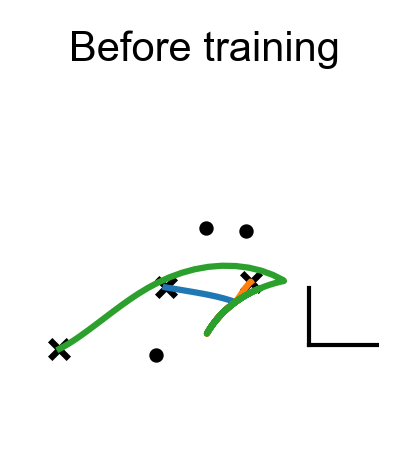

In [41]:
_ = plot_reaches(env_fingertip[:,:3], targets[:,:3],"Before training", ylims=(-0.2,1 ),
                 xlims=(-0.5,0.5),  scale_bars=True)
# plt.savefig("training_reach_init.pdf", bbox_inches="tight", transparent=True)


In [42]:
outputs, env_fingertip, targets = run_controller(controller, eval_bool=False, ckpt=final_ckpt)

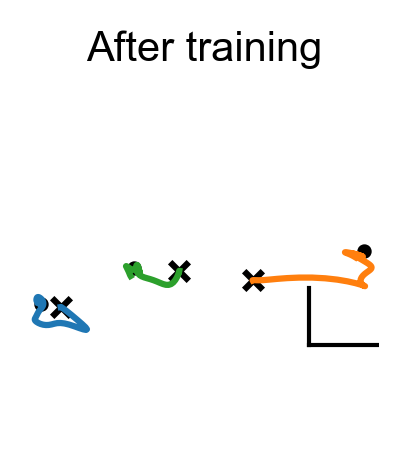

In [43]:
_ = plot_reaches(env_fingertip[:,:3], targets[:,:3],"After training", ylims=(-0.2,1 ),
                 xlims=(-0.5,0.5),  scale_bars=True,)
# plt.savefig("training_reach_end.pdf", bbox_inches="tight", transparent=True)

# Checkpoint evals 0 distractors

gd_500
('seed_7', 0.11623503267765045)
gd_0
('seed_9', 0.06799681484699249)
eg_500
('seed_8', 0.09487221390008926)
eg_0
('seed_79', 0.06867346167564392)

In [67]:
run_dict = results_dict.eg_0.seed_79
controller = load_controller_from_run(run_dict)

init_ckpt = run_dict.path/"controller_0.pth"
onek_ckpt = run_dict.path/"controller_1000.pth"
twok_ckpt = run_dict.path/"controller_2000.pth"
threek_ckpt = run_dict.path/"controller_3000.pth"
final_ckpt = run_dict.path/"controller_5999.pth"


muscle: cuda:0
skel init: cuda:0
effector init: cuda:0
env init: cuda:0


In [68]:
outputs, env_fingertip, targets = run_controller(controller, eval_bool=True, ckpt=threek_ckpt)

Eval circle targets


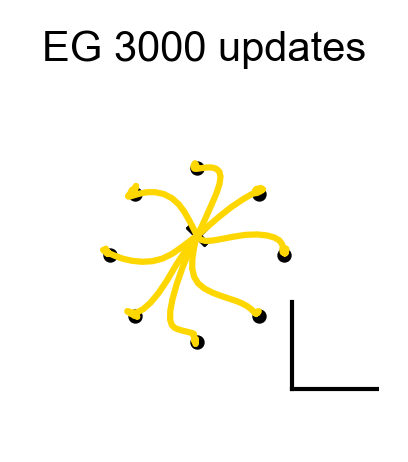

In [69]:
_ = plot_reaches(env_fingertip, targets, "EG 3000 updates", ylims=(-0., 0.8), xlims=(-0.4,0.4), c="gold", scale_bars=True)
plt.savefig("reach_0d_eg_3k.pdf", bbox_inches="tight", transparent=True)

In [70]:
outputs, env_fingertip, targets = run_controller(controller, eval_bool=True, ckpt=final_ckpt)

Eval circle targets


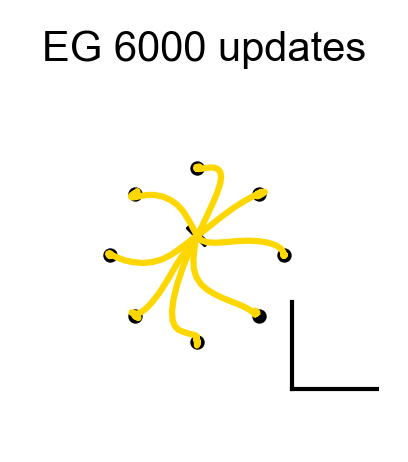

In [71]:
_ = plot_reaches(env_fingertip, targets, "EG 6000 updates", ylims=(-0., 0.8), xlims=(-0.4,0.4), c="gold", scale_bars=True)
plt.savefig("reach_0d_eg_6k.pdf", bbox_inches="tight", transparent=True)

In [72]:
run_dict = results_dict.gd_0.seed_9
controller = load_controller_from_run(run_dict)

init_ckpt = run_dict.path/"controller_0.pth"
onek_ckpt = run_dict.path/"controller_1000.pth"
twok_ckpt = run_dict.path/"controller_2000.pth"
threek_ckpt = run_dict.path/"controller_3000.pth"
final_ckpt = run_dict.path/"controller_5999.pth"

muscle: cuda:0
skel init: cuda:0
effector init: cuda:0
env init: cuda:0


In [73]:
outputs, env_fingertip, targets = run_controller(controller, eval_bool=True, ckpt=threek_ckpt)

Eval circle targets


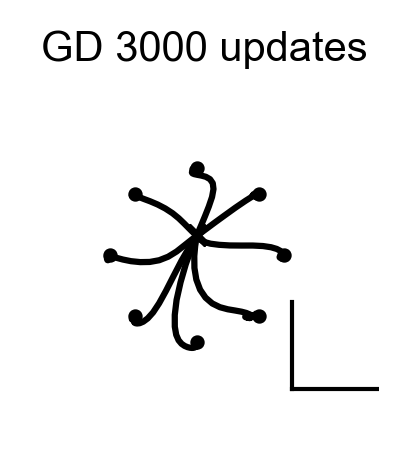

In [74]:
_ = plot_reaches(env_fingertip, targets, "GD 3000 updates", ylims=(-0., 0.8), xlims=(-0.4,0.4), c="k", scale_bars=True)
plt.savefig("reach_0d_gd_3k.pdf", bbox_inches="tight", transparent=True)

In [75]:
outputs, env_fingertip, targets = run_controller(controller, eval_bool=True, ckpt=final_ckpt)

Eval circle targets


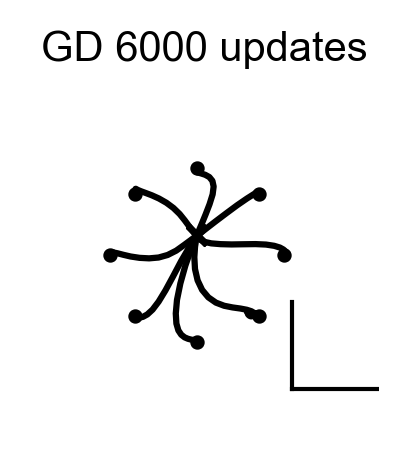

In [76]:
_ = plot_reaches(env_fingertip, targets, "GD 6000 updates", ylims=(-0., 0.8), xlims=(-0.4,0.4), c="k", scale_bars=True)
plt.savefig("reach_0d_gd_6k.pdf", bbox_inches="tight", transparent=True)

# Checkpoint evals 500


In [44]:
run_dict = results_dict.eg_500.seed_8
controller = load_controller_from_run(run_dict)

init_ckpt = run_dict.path/"controller_0.pth"
onek_ckpt = run_dict.path/"controller_1000.pth"
twok_ckpt = run_dict.path/"controller_2000.pth"
threek_ckpt = run_dict.path/"controller_3000.pth"
final_ckpt = run_dict.path/"controller_5999.pth"


muscle: cuda:0
skel init: cuda:0
effector init: cuda:0
env init: cuda:0


In [169]:
outputs, env_fingertip, targets = run_controller(controller, eval_bool=True, ckpt=threek_ckpt)

Eval circle targets


In [ ]:
_ = plot_reaches(env_fingertip, targets, "EG 3k", ylims=(-0., 0.8), xlims=(-0.4,0.4), c=eg_c, scale_bars=True)
plt.savefig("reach_eg_3k.pdf", bbox_inches="tight", transparent=True)

In [141]:
outputs, env_fingertip, targets = run_controller(controller, eval_bool=True, ckpt=final_ckpt)

Eval circle targets


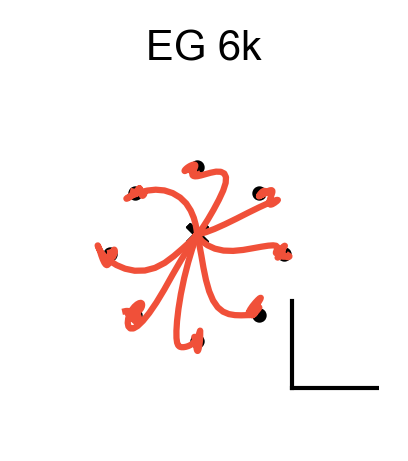

In [142]:
_ = plot_reaches(env_fingertip, targets, "EG 6k", ylims=(-0., 0.8), xlims=(-0.4,0.4), c=eg_c, scale_bars=True)
plt.savefig("reach_eg_6k.pdf", bbox_inches="tight", transparent=True)

In [143]:
outputs, env_fingertip, targets = run_controller(controller, eval_bool=True, ckpt=twok_ckpt)

Eval circle targets


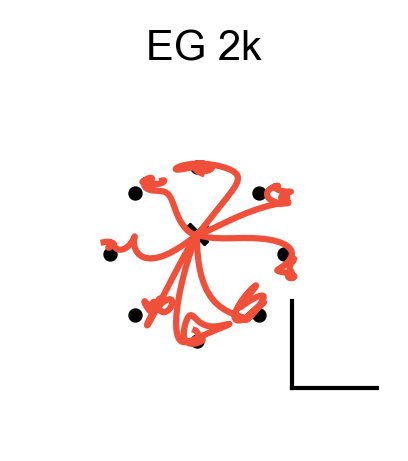

In [144]:
_ = plot_reaches(env_fingertip, targets, "EG 2k", ylims=(-0., 0.8), xlims=(-0.4,0.4), c=eg_c, scale_bars=True)
plt.savefig("reach_eg_2k.pdf", bbox_inches="tight", transparent=True)

In [ ]:
# GD

In [145]:
run_dict = results_dict.gd_500.seed_7
controller = load_controller_from_run(run_dict)

init_ckpt = run_dict.path/"controller_0.pth"
onek_ckpt = run_dict.path/"controller_1000.pth"
twok_ckpt = run_dict.path/"controller_2000.pth"
threek_ckpt = run_dict.path/"controller_3000.pth"
final_ckpt = run_dict.path/"controller_5999.pth"



muscle: cuda:0
skel init: cuda:0
effector init: cuda:0
env init: cuda:0


Eval circle targets


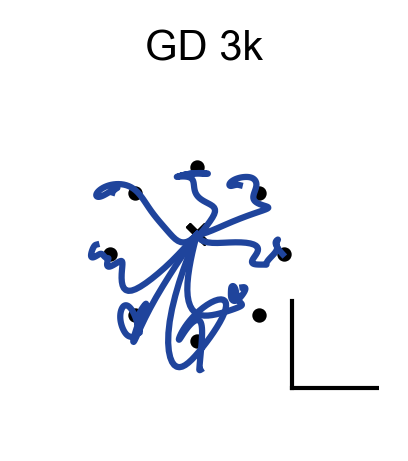

In [146]:
outputs, env_fingertip, targets = run_controller(controller, eval_bool=True, ckpt=threek_ckpt)

_ = plot_reaches(env_fingertip, targets, "GD 3k", ylims=(-0., 0.8), xlims=(-0.4,0.4), c=gd_c, scale_bars=True)
plt.savefig("reach_gd_3k.pdf", bbox_inches="tight", transparent=True)

Eval circle targets


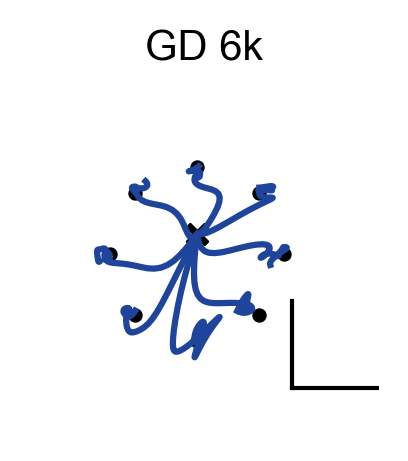

In [147]:
outputs, env_fingertip, targets = run_controller(controller, eval_bool=True, ckpt=final_ckpt)

_ = plot_reaches(env_fingertip, targets, "GD 6k", ylims=(-0., 0.8), xlims=(-0.4,0.4), c=gd_c, scale_bars=True)
plt.savefig("reach_gd_6k.pdf", bbox_inches="tight", transparent=True)

Eval circle targets


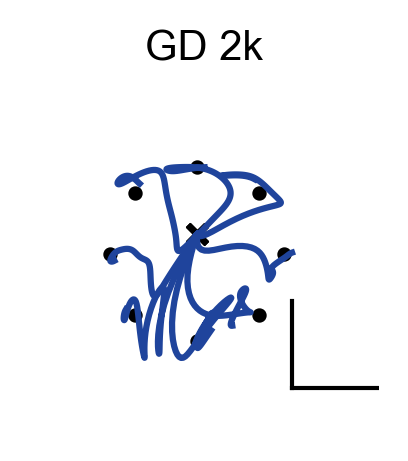

In [148]:
outputs, env_fingertip, targets = run_controller(controller, eval_bool=True, ckpt=twok_ckpt)

_ = plot_reaches(env_fingertip, targets, "GD 2k", ylims=(-0., 0.8), xlims=(-0.4,0.4), c=gd_c, scale_bars=True)
plt.savefig("reach_gd_2k.pdf", bbox_inches="tight", transparent=True)

In [158]:
# Arm feeback plots 
outputs, env_fingertip, targets = run_controller(controller, eval_bool=False, ckpt=init_ckpt)

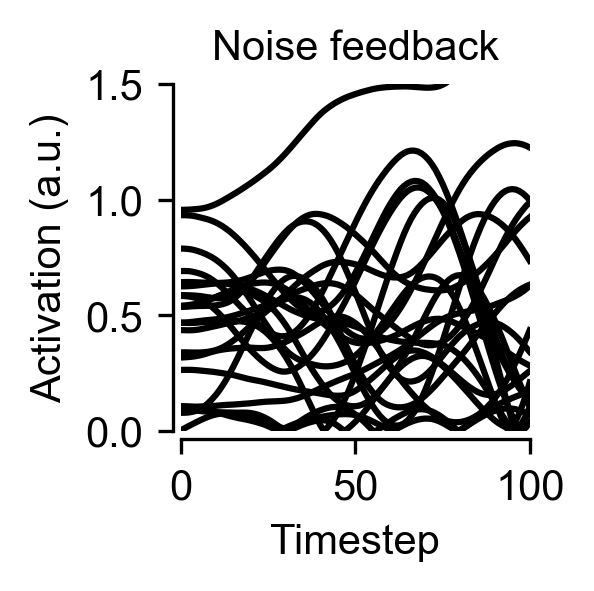

In [165]:
obs = torch.stack(outputs["observations"]).detach().cpu().numpy()

viz_batch_i = 3

fig = plt.figure(figsize=(1.5, 1.5), dpi=300)
plt.plot(obs[:,viz_batch_i,-22:], "k");
plt.title(f"Noise feedback")
plt.ylabel("Activation (a.u.)")
plt.xlabel("Timestep")

plt.xlim(0, 100)
plt.ylim(0, 1.5)

sns.despine(offset=2, trim=True)

plt.savefig("feedback_noise.pdf", bbox_inches="tight", transparent=True)

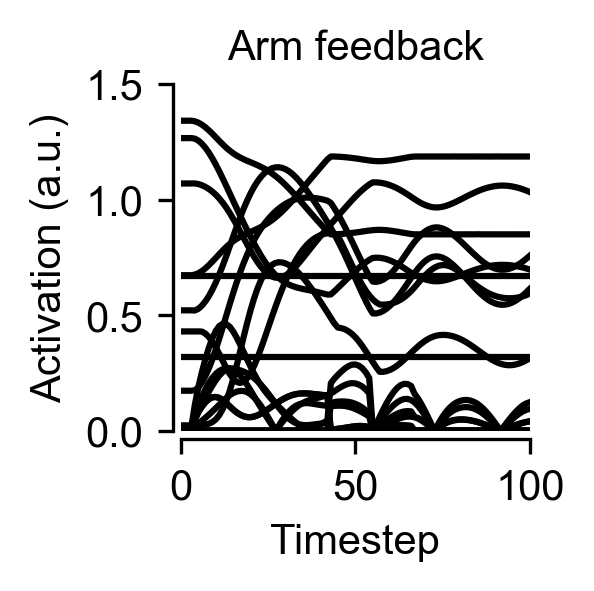

In [164]:
viz_batch_i = 3

fig = plt.figure(figsize=(1.5, 1.5), dpi=300)
plt.plot(obs[:,viz_batch_i,:22], "k");
plt.title(f"Arm feedback")
plt.ylabel("Activation (a.u.)")
plt.xlabel("Timestep")

plt.xlim(0, 100)
plt.ylim(0, 1.5)

sns.despine(offset=2, trim=True)
plt.savefig("feedback_true.pdf", bbox_inches="tight", transparent=True)

In [ ]:
# Below here not used for figure

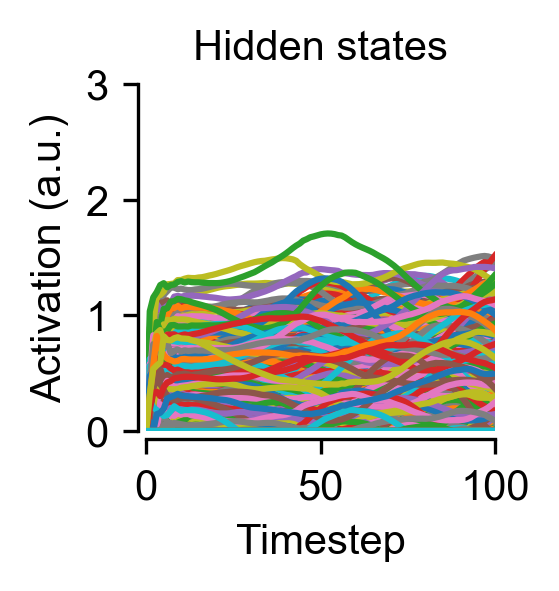

In [166]:
hidden_states = np.stack([detach(obs) for obs in outputs["policy_states"]])
hidden_states = hidden_states.squeeze() # (n_timesteps, batch_size, hidden_dim)
fig = plt.figure(figsize=(1.5, 1.5), dpi=300)
plt.plot(hidden_states[:, viz_batch_i, :])
plt.title(f"Hidden states") # (target {viz_batch_i})")
plt.xlabel("Timestep")
plt.ylabel("Activation (a.u.)")


plt.xlim(0, 100)
plt.ylim(0, 3)

sns.despine(offset=2, trim=True)
plt.savefig("state_hidden.pdf", bbox_inches="tight", transparent=True)

# actions = np.stack([detach(o) for o in outputs["actions"]]).squeeze()
# xy = np.stack(actions)[:, viz_batch_i, :]
# axs[i,2].plot(xy)
# axs[i,2].set_title(f"Muscle drive (target {viz_batch_i})")
# axs[i,2].set_xlabel("Timestep")

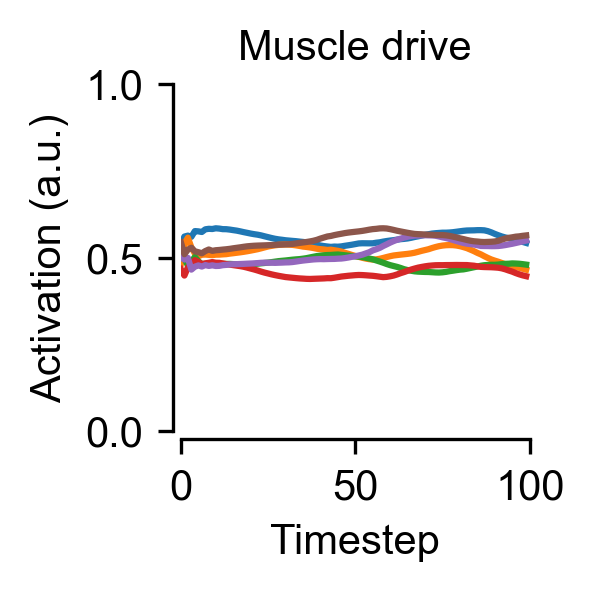

In [167]:
actions = np.stack([detach(o) for o in outputs["actions"]]).squeeze()
xy = np.stack(actions)[:, viz_batch_i, :]

fig = plt.figure(figsize=(1.5, 1.5), dpi=300)
plt.plot(xy)
plt.title(f"Muscle drive") # (target {viz_batch_i})")
plt.ylabel("Activation (a.u.)")
plt.xlabel("Timestep")

plt.xlim(0, 100)
plt.ylim(0, 1)

plt.yticks([0, 0.5,1.0])

sns.despine(offset=2, trim=True)
plt.savefig("state_muscle_output.pdf", bbox_inches="tight", transparent=True)